<a href="https://colab.research.google.com/github/imchrisrueda/extML/blob/main/entornos_complejos/B-MC.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Parte B – Métodos Tabulares


**Grupo 2 · MIA UMU 2025/2026**

---

## Objetivo

En este notebook se implementa Monte Carlo (on-policy y off-policy) utilizando el entorno del taxi de Gymnasium.

Lo primero es tener claro cuál es la diferencia entre los dos enfoques:
* On-policy: el agente aprende sobre la misma política que usa para explorar
* Off-policy: el agente aprende sobre una política objetivo mientras explora con una política comportamiento diferente. Se ha aplicado off-policy ponderado.

Información sobre este entorno la podemos encontrar [aquí](https://gymnasium.farama.org/environments/toy_text/taxi/). La idea es que hay diferentes casillas donde puede encontrarse un pasajero, y hay un taxi que tiene que recogerle y dejarle en su destino.

Nos encontramos en un espacio discreto, donde hay exactamente 6 acciones posibles: moverse a izquierda, derecha, arriba, abajo, recoger al pasajero y dejarlo en su destino. además hay 500 estados posibles: el taxi puede moverse en 5x5=25 casillas, el pasajero puede encontrarse en 5 lugares diferentes (casilla azul, verde, roja, amarilla o dentro del taxi) y el destino puede estar en 4 casillas diferentes (casilla azul, verde, roja o amarilla). Eentonces, 25x5x4=500

En cuanto a las recompensas:
* -1 por cada casilla que el taxi recorra
* +20 si esa casilla es el destino del pasajero y lo deja ahí
* -10 si realiza alguna acción ilegal

Logicamente el episodio termina cuando el taxi deja al pasajero en su destino. Pero también se finaliza si se llega a 200 episodios.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

from src.agent import AgentMC

# Semilla
semilla = 123
np.random.seed(semilla)

In [ ]:
# Para crear el entorno del taxi
import gymnasium as gym
env = gym.make('Taxi-v3')

n_episodios  = 10_000
gamma        = 1.0 # factor de descuento
epsilon      = 1.0 # exploración inicial (alto porque al principio el agente no sabe nada)
decay        = True # epsilon decrece

n_estados = env.observation_space.n
n_acciones = env.action_space.n

print(f"Número de estados: {n_estados}")
print(f"Número de acciones: {n_acciones}")

Número de estados: 500
Número de acciones: 6


In [ ]:
agent_on = AgentMC(env, epsilon, gamma, decay = True)
agent_off = AgentMC(env, epsilon, gamma, decay = True) # ponderado

### Primero, la forma on-policy:

In [ ]:
# ON POLICY
recompensas_por_episodio_on = []
longitud_por_episodio_on = []

for episodio in range(n_episodios):

    obs, _ = env.reset()  # en cada episodio, volvemos a empezar
    done = False

    agent_on.decay_epsilon(episodio)

    ep_reward = 0
    ep_length = 0

    # mientras no haya terminado el episodio
    while not done: 
        # El agente elige acción según su política epsilon-greedy
        accion = agent_on.get_action(obs)

        # llamar a la función step para tomar esa accion
        next_obs, recompensa, terminado, truncado, info = env.step(accion)

        # El agente acumula la transición y actualiza Q si done=True
        agent_on.update(obs, accion, next_obs, recompensa, terminado, truncado, None)

        obs  = next_obs
        done = terminado or truncado
        ep_reward += recompensa   
        ep_length += 1

    # cuando si termina el episodio --> 
    recompensas_por_episodio_on.append(ep_reward) # guardar recompensa
    longitud_por_episodio_on.append(ep_length) # guarar longitud

### Ahora off-policy
Cambia respecto a on policy, porque, recordemos antes solo se usaba una política, pero ahora hay dos. Para aprender se usa una `política objetivo` y para explorar una `política comportamiento` diferente.

In [ ]:
recompensas_por_episodio_off = []
longitud_por_episodio_off = []

for episodio in range(n_episodios):
    obs, info = env.reset() # reiniciar
    done = False
    agent_off.decay_epsilon(episodio) # se reduce epsilon ε antes de empezar el episodio - al principio epsilon≈1 (casi todo aleatorio) y al final casi 0
    ep_reward = 0
    ep_length = 0

    while not done:
        accion = agent_off.behavior_action(obs) # uso la política de comportamiento b) para elegir acción
        next_obs, recompensa, terminado, truncado, info = env.step(accion) # dar un paso
        agent_off.update_off(obs, accion, next_obs, recompensa, terminado, truncado, info)
        
        obs = next_obs
        done = terminado or truncado
        ep_reward += recompensa
        ep_length += 1

    recompensas_por_episodio_off.append(ep_reward)
    longitud_por_episodio_off.append(ep_length)

In [ ]:
# Test: ¿cuántos estados ha visitado on-policy?
visitados_on = np.sum(agent_on.returns_count > 0)
visitados_off = np.sum(agent_off.C > 0)  # esto es C para off
estados_totales = agent_on.nS * agent_on.nA  # 500 * 6 = 3000

print(f"Pares (s,a) visitados on-policy : {visitados_on} / {estados_totales}")
print(f"Pares (s,a) visitados off-policy: {visitados_off} / {estados_totales}")

# ¿Cuántos estados tienen Q > 0?
q_positivo_on  = np.sum(agent_on.Q  > 0)
q_positivo_off = np.sum(agent_off.Q > 0)
print(f"Q > 0 en on-policy : {q_positivo_on}")
print(f"Q > 0 en off-policy: {q_positivo_off}")

# Ver los 5 valores Q más altos de on-policy
print(f"\nTop 5 valores Q on-policy:")
idx = np.unravel_index(np.argsort(agent_on.Q.ravel())[-5:], agent_on.Q.shape)
for s, a in zip(idx[0], idx[1]):
    print(f"  Q[estado={s}, accion={a}] = {agent_on.Q[s,a]:.3f}")



Pares (s,a) visitados on-policy : 2400 / 3000
Pares (s,a) visitados off-policy: 2211 / 3000
Q > 0 en on-policy : 19
Q > 0 en off-policy: 1014

Top 5 valores Q on-policy:
  Q[estado=318, accion=0] = 15.637
  Q[estado=479, accion=5] = 20.000
  Q[estado=418, accion=5] = 20.000
  Q[estado=16, accion=5] = 20.000
  Q[estado=97, accion=5] = 20.000


## Gráficos

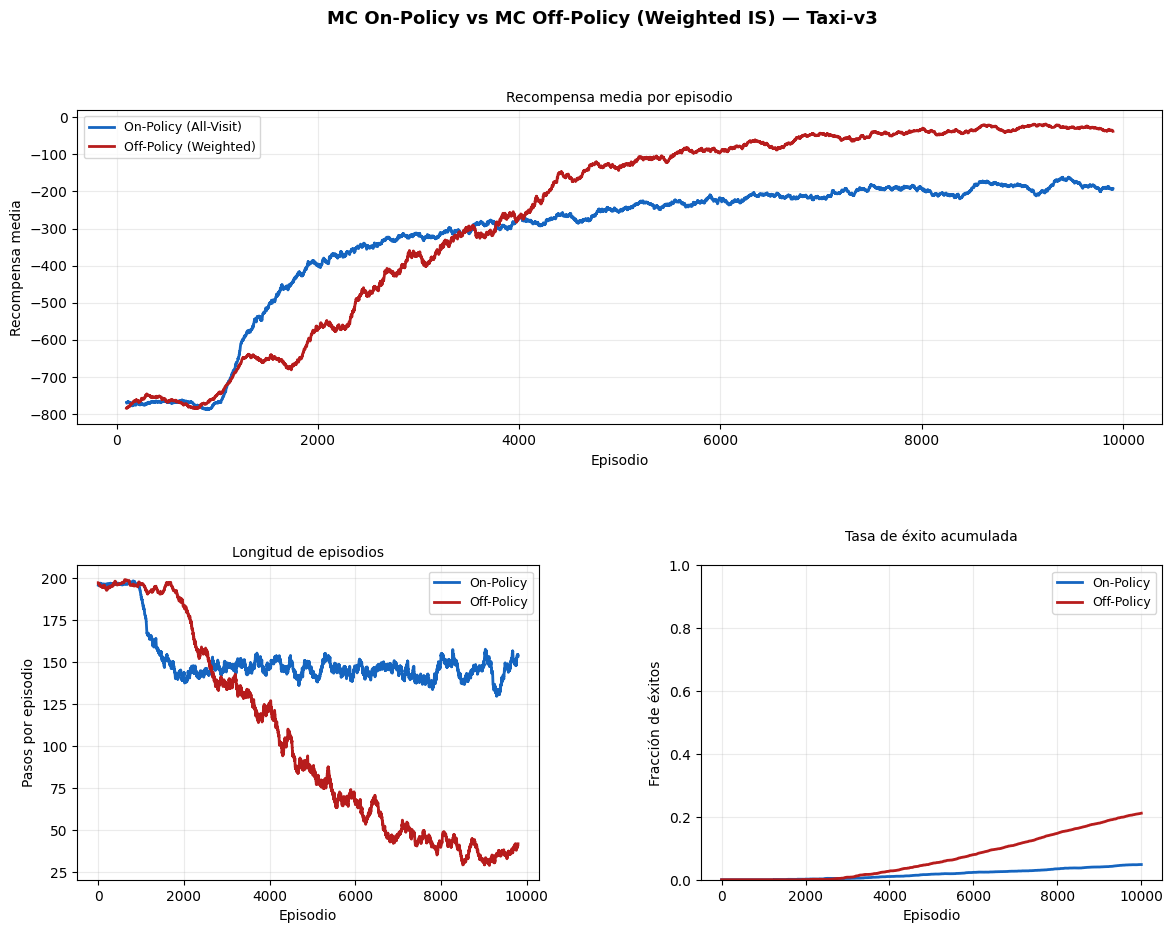


RESUMEN COMPARATIVO
Métrica                              On-Policy Off-Policy
------------------------------------------------------------
Reward medio (últimos 1000 ep)         -185.35     -27.51
Longitud media (últimos 1000 ep)         145.2       35.4
Tasa de éxito final (últimos 1000 ep)     11.90%     49.50%


In [ ]:
def media_movil(valores, ventana=200):
    return np.convolve(valores, np.ones(ventana) / ventana, mode='valid')


# Figura comparativa: On-Policy vs Off-Policy
fig = plt.figure(figsize=(14, 10))
fig.suptitle("MC On-Policy vs MC Off-Policy (Weighted IS) — Taxi-v3",
             fontsize=13, fontweight='bold')

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

COLOR_ON  = '#1565C0'  # azul
COLOR_OFF = '#B71C1C'  # rojo
VENTANA   = 200


# Gráfico 1: Recompensa por episodio
# Muestra la evolución del aprendizaje de los dos agentes a la vez
# Muestra cómo mejora la recompensa a lo largo del entrenamiento
# Se suaviza con media móvil porque episodio a episodio hay mucho ruido
ax1 = fig.add_subplot(gs[0, :])  # ocupa toda la primera fila

on_suav  = media_movil(recompensas_por_episodio_on,  VENTANA)
off_suav = media_movil(recompensas_por_episodio_off, VENTANA)
x_on     = np.arange(VENTANA // 2, len(on_suav)  + VENTANA // 2)
x_off    = np.arange(VENTANA // 2, len(off_suav) + VENTANA // 2)

ax1.plot(x_on,  on_suav,  color=COLOR_ON,  lw=2, label='On-Policy (All-Visit)')
ax1.plot(x_off, off_suav, color=COLOR_OFF, lw=2, label='Off-Policy (Weighted)')
ax1.set_title(f'Recompensa media por episodio', fontsize=10)
ax1.set_xlabel('Episodio')
ax1.set_ylabel('Recompensa media')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)


# Gráfico 2: Longitud de episodios 
# Si el agente aprende bien cada episodio dura menos pasos
ax2 = fig.add_subplot(gs[1, 0])

lon_on_suav  = media_movil(longitud_por_episodio_on,  VENTANA)
lon_off_suav = media_movil(longitud_por_episodio_off, VENTANA)

ax2.plot(np.arange(len(lon_on_suav)),  lon_on_suav,
         color=COLOR_ON,  lw=2, label='On-Policy')
ax2.plot(np.arange(len(lon_off_suav)), lon_off_suav,
         color=COLOR_OFF, lw=2, label='Off-Policy')
ax2.set_title('Longitud de episodios', fontsize=10)
ax2.set_xlabel('Episodio')
ax2.set_ylabel(f'Pasos por episodio')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)


# Gráfico 3: Porcentaje de episodios con recompensa positiva
# La recompensa final es +20 si se entrega bien y −10 si no
# Un episodio exitoso es el que tiene recompensa total > 0
ax3 = fig.add_subplot(gs[1, 1])

exitos_on  = np.array(recompensas_por_episodio_on)  > 0
exitos_off = np.array(recompensas_por_episodio_off) > 0

tasa_on  = np.cumsum(exitos_on) / (np.arange(len(exitos_on))  + 1)
tasa_off = np.cumsum(exitos_off) / (np.arange(len(exitos_off)) + 1)

ax3.plot(tasa_on,  color=COLOR_ON,  lw=2, label='On-Policy')
ax3.plot(tasa_off, color=COLOR_OFF, lw=2, label='Off-Policy')
ax3.set_title('Tasa de éxito acumulada\n', fontsize=10)
ax3.set_xlabel('Episodio')
ax3.set_ylabel('Fracción de éxitos')
ax3.set_ylim(0, 1)
ax3.legend(fontsize=9)
ax3.grid(alpha=0.25)

plt.show()


# Tabla resumen de resultados
ultimos = 1000  # miramos los últimos N episodios para el resumen final

print("\n" + "="*60)
print("RESUMEN COMPARATIVO")
print("="*60)
print(f"{'Métrica':<35} {'On-Policy':>10} {'Off-Policy':>10}")
print("-"*60)
print(f"{'Reward medio (últimos 1000 ep)':<35} "
      f"{np.mean(recompensas_por_episodio_on[-ultimos:]):>10.2f} "
      f"{np.mean(recompensas_por_episodio_off[-ultimos:]):>10.2f}")
print(f"{'Longitud media (últimos 1000 ep)':<35} "
      f"{np.mean(longitud_por_episodio_on[-ultimos:]):>10.1f} "
      f"{np.mean(longitud_por_episodio_off[-ultimos:]):>10.1f}")
print(f"{'Tasa de éxito final (últimos 1000 ep)':<35} "
      f"{np.mean(np.array(recompensas_por_episodio_on[-ultimos:]) > 0):>10.2%} "
      f"{np.mean(np.array(recompensas_por_episodio_off[-ultimos:]) > 0):>10.2%}")
print("="*60)


Como conclusión analizando los gráficos, vemos que ocurre lo que tiene que pasar, que los episodios cada vez duran menos y que la recompensa obtenida por episodio es cada vez mayor. Entrando más en detalle:
* On-policy converge más rápido en las primeras fases, ya en el episodio 2000 (más o menos), se llega a una recompensa de -400; mientras que en off-policy en esos momentos ronda los -580 de recompensa. Esto se debe a que on-policy aprende directamente de su propia política epsilon-greedy, sin necesidad de corregir por importancia de muestras. 

* Pero el primero método nunca llega a ser tan bueno como el segundo. La recompensa por episodio en off-policy a partir del 4000 (más o menos) comienza siendo mayor y nunca se le supera, llegando casi al 0, y on-policy como mucho alcanza casi -200.

* En cuanto a la duración de los episodios, on-policy tiene una caída rápida y brusca anterior, pero se estanca, y la mayoría duran entre 135 y 150 pasos. Esto indica que la política epsilon-greedy residual (epsilon=0.01) sigue introduciendo suficiente ruido como para alargar los episodios. En cambio, en off-policy, el descenso es más gradual, incluso llega a alcanzar una duración de casi 25 pasos, que es muy bajo teniniendo en cuenta que el entorno tiene 5x5 = 25 casillas.

* En cuanto a la tasa de éxito, esta no es muy alta con ninguno de los dos enfoques. Esto se debe a que MC necesita episodios completos para aprender, lo que lo hace menos eficiente. Pero off-policy funciona mejor.

* La razón de estos resultados es que on-policy aprende el valor de una política epsilon-greedy (no la óptima), mientras que off-policy aprende directamente la política greedy óptima usando datos generados por una política de comportamiento aleatoria. Esta separación  es la ventaja fundamental del enfoque off-policy.

* Sobre el tercer gráfico, como es lógico por lo obtenido en los anteriores dos, la tasa de éxito de on-policy es menor. Debido a que obtiene menor recomepnsa y que los episodios duran más.